In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/kaggle/input/usedcarssa-clean-en/UsedCarsSA_Clean_EN.csv")

In [3]:
df

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,0,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   object 
 1   Type         8035 non-null   object 
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   object 
 4   Color        8035 non-null   object 
 5   Options      8035 non-null   object 
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   object 
 8   Gear_Type    8035 non-null   object 
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   object 
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 761.3+ KB


In [5]:
df.duplicated().sum()

3

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,8032.000000,8032.000000,8.032000e+03,8.032000e+03
mean,2014.097112,3.287774,1.491528e+05,5.369923e+04
std,5.758021,1.518001,3.475122e+05,7.199385e+04
min,1963.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,0.000000e+00
50%,2016.000000,3.000000,1.017855e+05,3.700000e+04
75%,2018.000000,4.400000,1.950000e+05,7.362500e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


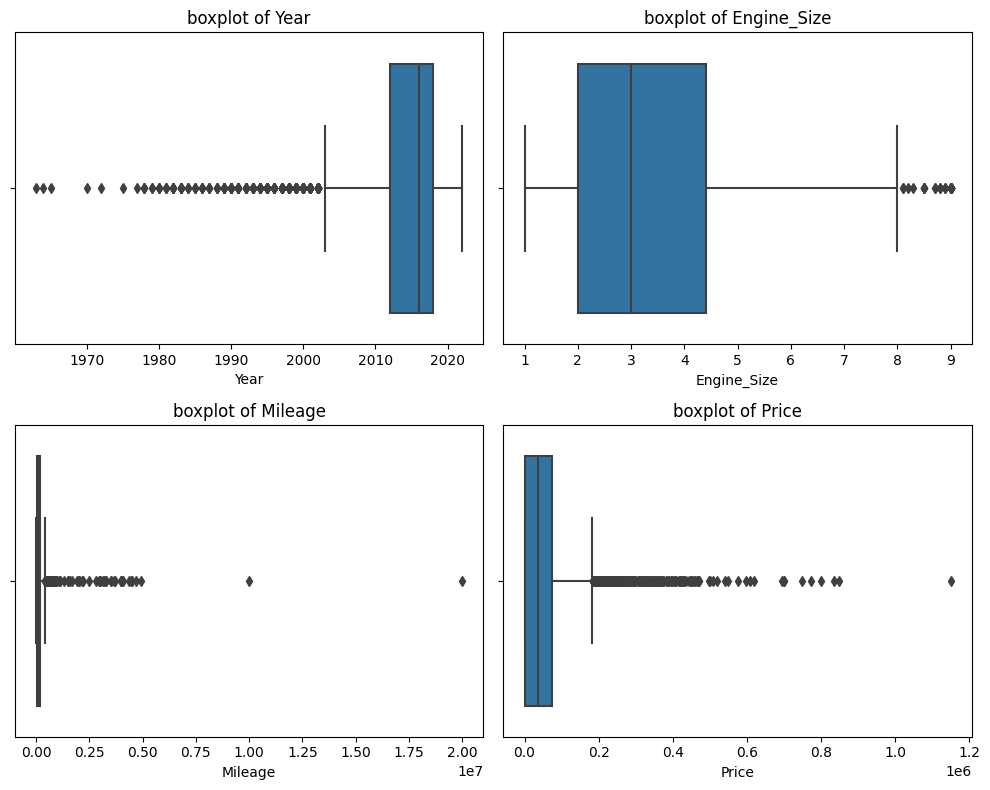

In [8]:
cols = ['Year' , 'Engine_Size' , 'Mileage' , 'Price' ]

plt.figure(figsize=(10,8))
for i ,col in enumerate(cols , 1):
    plt.subplot(2,2 , i)
    sns.boxplot(data=df , x=col)
    plt.title(f'boxplot of {col}')
    plt.tight_layout()
plt.show()

In [9]:
for i in cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    iqr = Q3 - Q1
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr

    df[i] = df[i].clip(lower=lower_bound, upper=upper_bound)

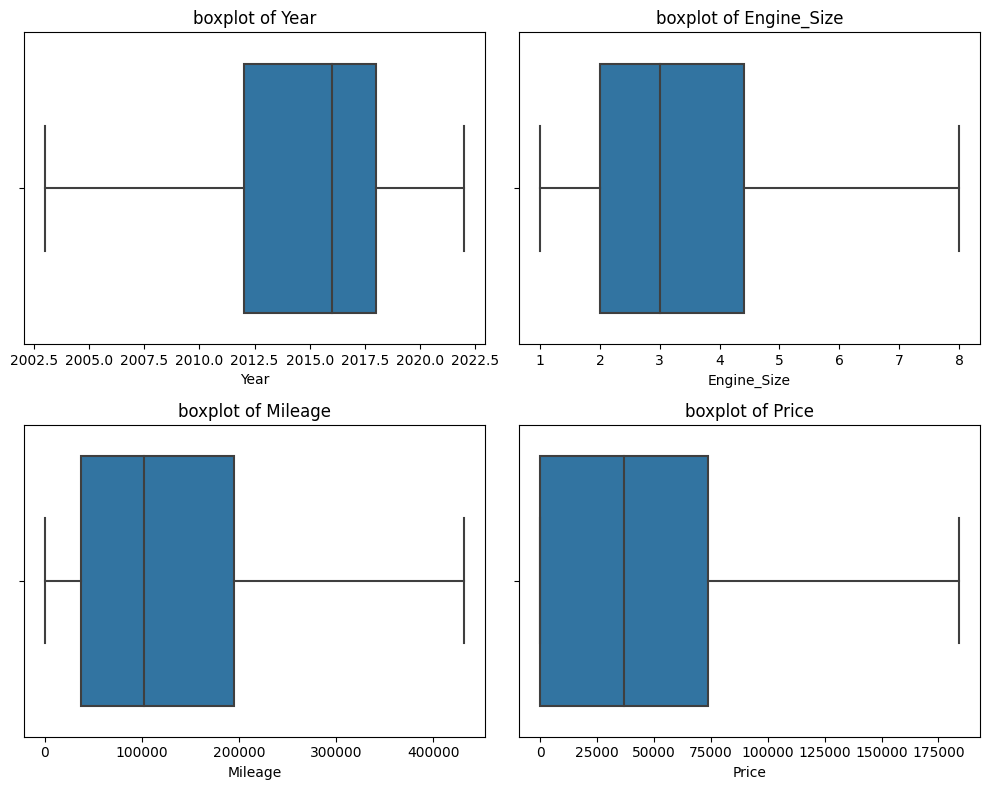

In [10]:
cols = ['Year' , 'Engine_Size' , 'Mileage' , 'Price' ]

plt.figure(figsize=(10,8))
for i ,col in enumerate(cols , 1):
    plt.subplot(2,2 , i)
    sns.boxplot(data=df , x=col)
    plt.title(f'boxplot of {col}')
    plt.tight_layout()
plt.show()

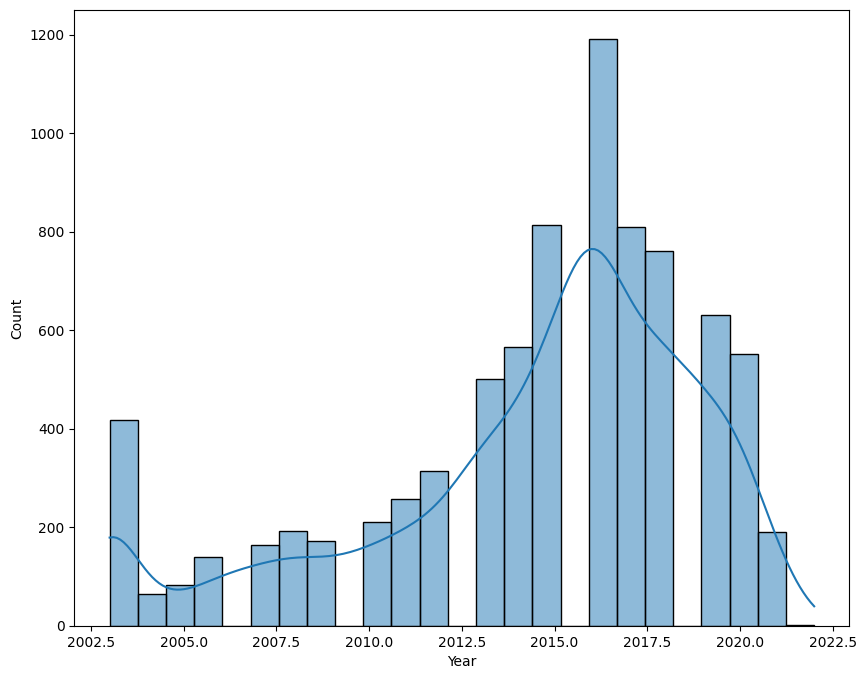

In [11]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Year' , kde=True , bins=25)
plt.show()

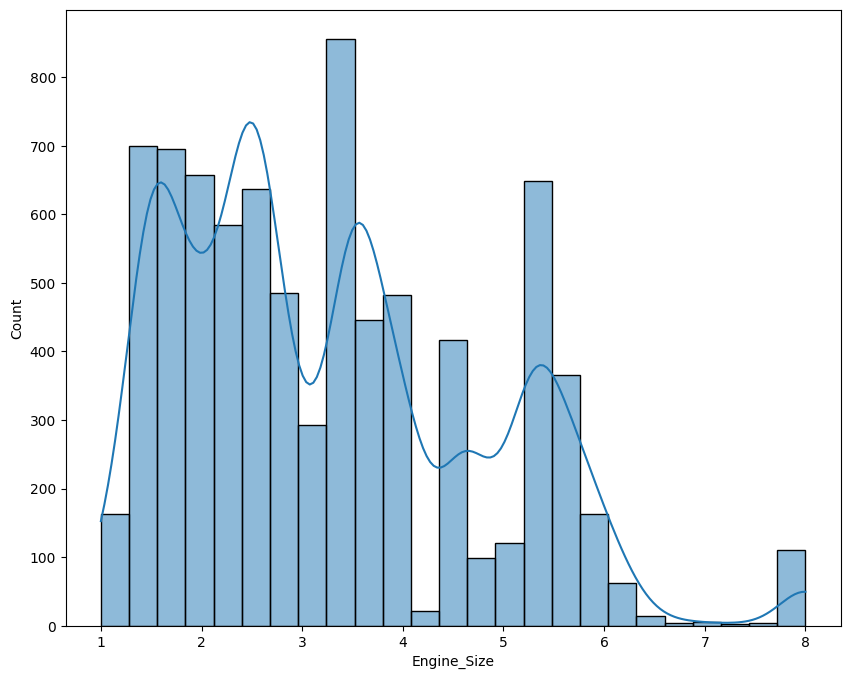

In [12]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Engine_Size' , kde=True , bins=25)
plt.show()

In [13]:
df

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0.0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,0.0,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False


In [14]:
df['Price'].agg(['mean' , 'min' , 'max'])

mean     48847.239915
min          0.000000
max     184062.500000
Name: Price, dtype: float64

In [15]:
df.describe(include='O')

,Make,Type,Origin,Color,Options,Fuel_Type,Gear_Type,Region
count,8032,8032,8032,8032,8032,8032,8032,8032
unique,59,381,4,15,3,3,2,27
top,Toyota,Land Cruiser,Saudi,White,Full,Gas,Automatic,Riyadh
freq,2037,372,5961,3477,3191,7858,6968,3236


In [16]:
df['Fuel_Type'].value_counts()

Fuel_Type
Gas       7858
Diesel     151
Hybrid      23
Name: count, dtype: int64

In [17]:
df.pivot_table(index='Make' , values='Price' ,aggfunc=['min' , 'max']).reset_index()

,Make,min,max
,,Price,Price
0,Aston Martin,180000.0,184062.5
1,Audi,0.0,184062.5
2,BMW,0.0,184062.5
3,BYD,0.0,28000.0
4,Bentley,100000.0,184062.5
5,Cadillac,0.0,184062.5
6,Changan,0.0,98000.0
7,Chery,11000.0,42500.0
8,Chevrolet,0.0,184062.5


In [18]:
df[df['Price'] == 184062.500000]

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
13,Mercedes,CLA,2020,Other,White,Standard,2.0,Gas,Automatic,20000,Riyadh,184062.5,False
14,Mercedes,E,2017,Saudi,Grey,Full,2.0,Gas,Automatic,20600,Dammam,184062.5,False
25,Land Rover,Range Rover,2014,Saudi,Black,Full,3.0,Gas,Automatic,80000,Makkah,184062.5,False
73,Lexus,ES,2019,Saudi,Another Color,Full,3.5,Gas,Automatic,26000,Jeddah,184062.5,False
82,Mercedes,S,2018,Saudi,Grey,Full,3.0,Gas,Automatic,73000,Riyadh,184062.5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7619,Jeep,Wrangler,2020,Gulf Arabic,Black,Semi Full,3.6,Gas,Automatic,4000,Dammam,184062.5,False
7681,Other,Other,2003,Other,Yellow,Standard,2.4,Diesel,Manual,2500,Qassim,184062.5,False
7814,Ford,Expedition,2021,Saudi,Another Color,Semi Full,1.6,Gas,Automatic,2500,Aseer,184062.5,False
7836,BMW,The 7,2018,Saudi,Navy,Semi Full,6.8,Gas,Automatic,18000,Riyadh,184062.5,False


In [19]:
df[df['Price'] == 0.000000e+00]

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0.0,True
7,GMC,Yukon,2009,Saudi,Bronze,Full,5.7,Gas,Automatic,323000,Riyadh,0.0,True
18,GMC,Yukon,2018,Saudi,White,Full,5.3,Gas,Automatic,37000,Riyadh,0.0,True
26,Toyota,Camry,2019,Saudi,Red,Full,2.5,Gas,Automatic,8000,Makkah,0.0,True
28,Toyota,Avalon,2008,Other,Red,Full,3.5,Gas,Automatic,169000,Riyadh,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8018,Mazda,CX9,2015,Saudi,Red,Standard,3.6,Gas,Automatic,195000,Al-Medina,0.0,True
8021,Ford,Explorer,2010,Other,Black,Semi Full,1.6,Gas,Automatic,432000,Al-Baha,0.0,True
8022,Toyota,Furniture,2020,Saudi,White,Semi Full,2.7,Gas,Automatic,82000,Makkah,0.0,True
8024,Toyota,Furniture,2014,Saudi,White,Semi Full,4.0,Gas,Automatic,432000,Riyadh,0.0,True


In [20]:
df['Region'].value_counts()

Region
Riyadh            3236
Dammam            1368
Jeddah            1054
Qassim             309
Al-Medina          297
Al-Ahsa            235
Aseer              231
Makkah             227
Taef               137
Tabouk             130
Khobar              92
Jubail              91
Jazan               90
Abha                86
Hail                85
Hafar Al-Batin      66
Najran              57
Al-Baha             48
Al-Jouf             37
Yanbu               36
Arar                32
Besha               23
Al-Namas            17
Wadi Dawasir        17
Qurayyat            14
Sakaka              12
Sabya                5
Name: count, dtype: int64

In [21]:
df2 = df[df['Negotiable'] == False]
df2

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,Kia,Sorento,2006,Saudi,Navy,Full,3.5,Gas,Manual,257000,Dammam,15000.0,False
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False


In [22]:
df['Year'].agg(['min' , 'max'])

min    2003
max    2022
Name: Year, dtype: int64

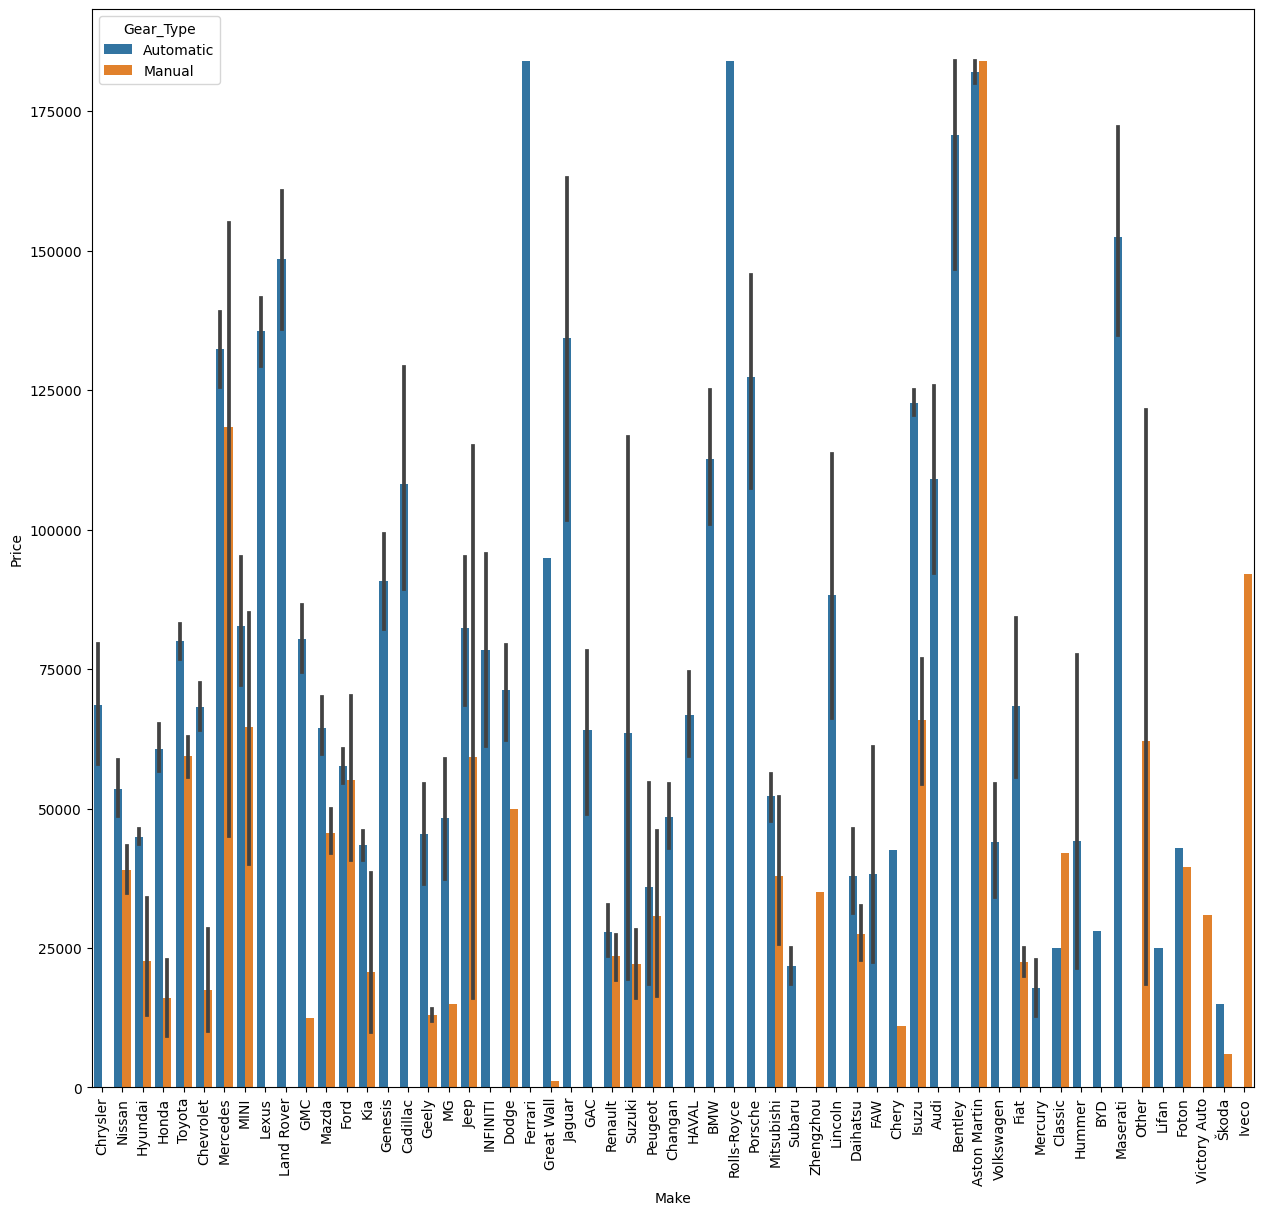

In [23]:
plt.figure(figsize=(15,14))
sns.barplot(data=df2 , x='Make' , y='Price' , hue='Gear_Type')
plt.xticks(rotation=90)
plt.show()

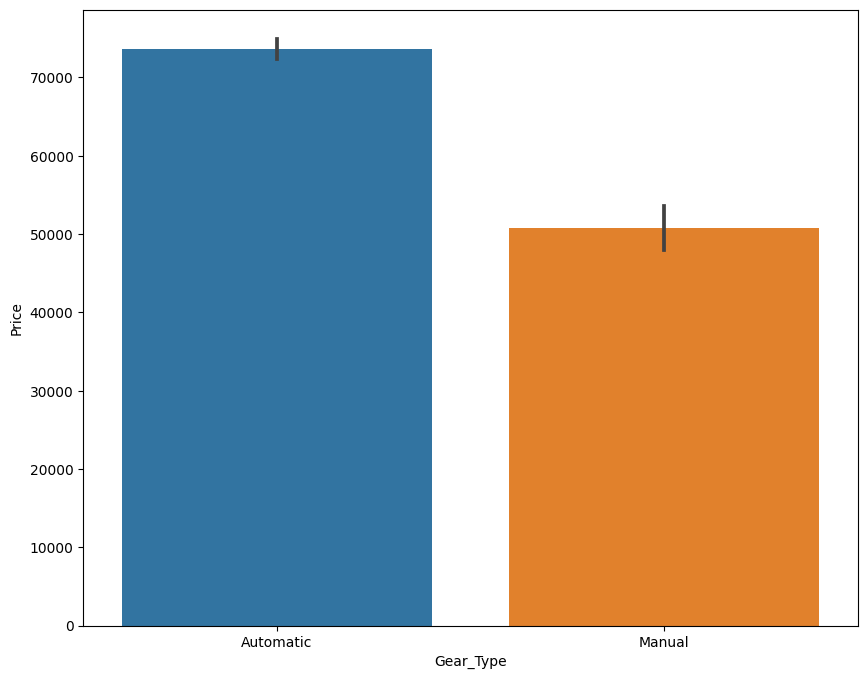

In [24]:
plt.figure(figsize=(10,8))
sns.barplot(data=df2  , x='Gear_Type' , y='Price' )
plt.show()

In [25]:
df['Make'].value_counts()

Make
Toyota          2037
Hyundai          941
Ford             761
Chevrolet        644
Nissan           548
GMC              400
Kia              357
Lexus            343
Mercedes         328
Mazda            184
Honda            183
BMW              132
Mitsubishi       125
Dodge            121
Land Rover        98
Jeep              77
Chrysler          71
Genesis           55
Renault           55
Changan           54
Audi              52
Cadillac          46
Isuzu             41
Porsche           33
MG                31
Volkswagen        29
Geely             28
INFINITI          23
Lincoln           22
Suzuki            22
HAVAL             19
Daihatsu          16
Mercury           15
Peugeot           15
Other             15
MINI              15
Jaguar            14
Fiat              12
Maserati           8
Hummer             8
Bentley            7
GAC                6
Great Wall         5
FAW                5
BYD                4
Rolls-Royce        4
Aston Martin       3
Zhengzho

In [26]:
toyota = df2[df2['Make'] == 'Toyota']
toyota

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
6,Toyota,Land Cruiser,2011,Saudi,White,Semi Full,4.5,Gas,Automatic,183000,Riyadh,92000.0,False
9,Toyota,Yaris,2018,Saudi,White,Standard,1.5,Gas,Automatic,131000,Jeddah,32000.0,False
10,Toyota,Camry,2017,Gulf Arabic,White,Standard,2.5,Gas,Automatic,107000,Dammam,50000.0,False
15,Toyota,Corolla,2018,Saudi,White,Standard,1.6,Gas,Automatic,7702,Dammam,45000.0,False
20,Toyota,Prado,2021,Saudi,White,Semi Full,4.0,Gas,Automatic,3000,Dammam,174000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,Toyota,Rav4,2011,Saudi,Another Color,Semi Full,1.4,Gas,Manual,135000,Riyadh,25000.0,False
7988,Toyota,Avalon,2016,Saudi,White,Semi Full,3.5,Gas,Automatic,86000,Jeddah,87000.0,False
8010,Toyota,Furniture,2012,Saudi,Black,Semi Full,2.0,Gas,Automatic,202245,Riyadh,41000.0,False
8014,Toyota,Camry,2017,Saudi,Silver,Standard,2.5,Gas,Automatic,314000,Dammam,46000.0,False


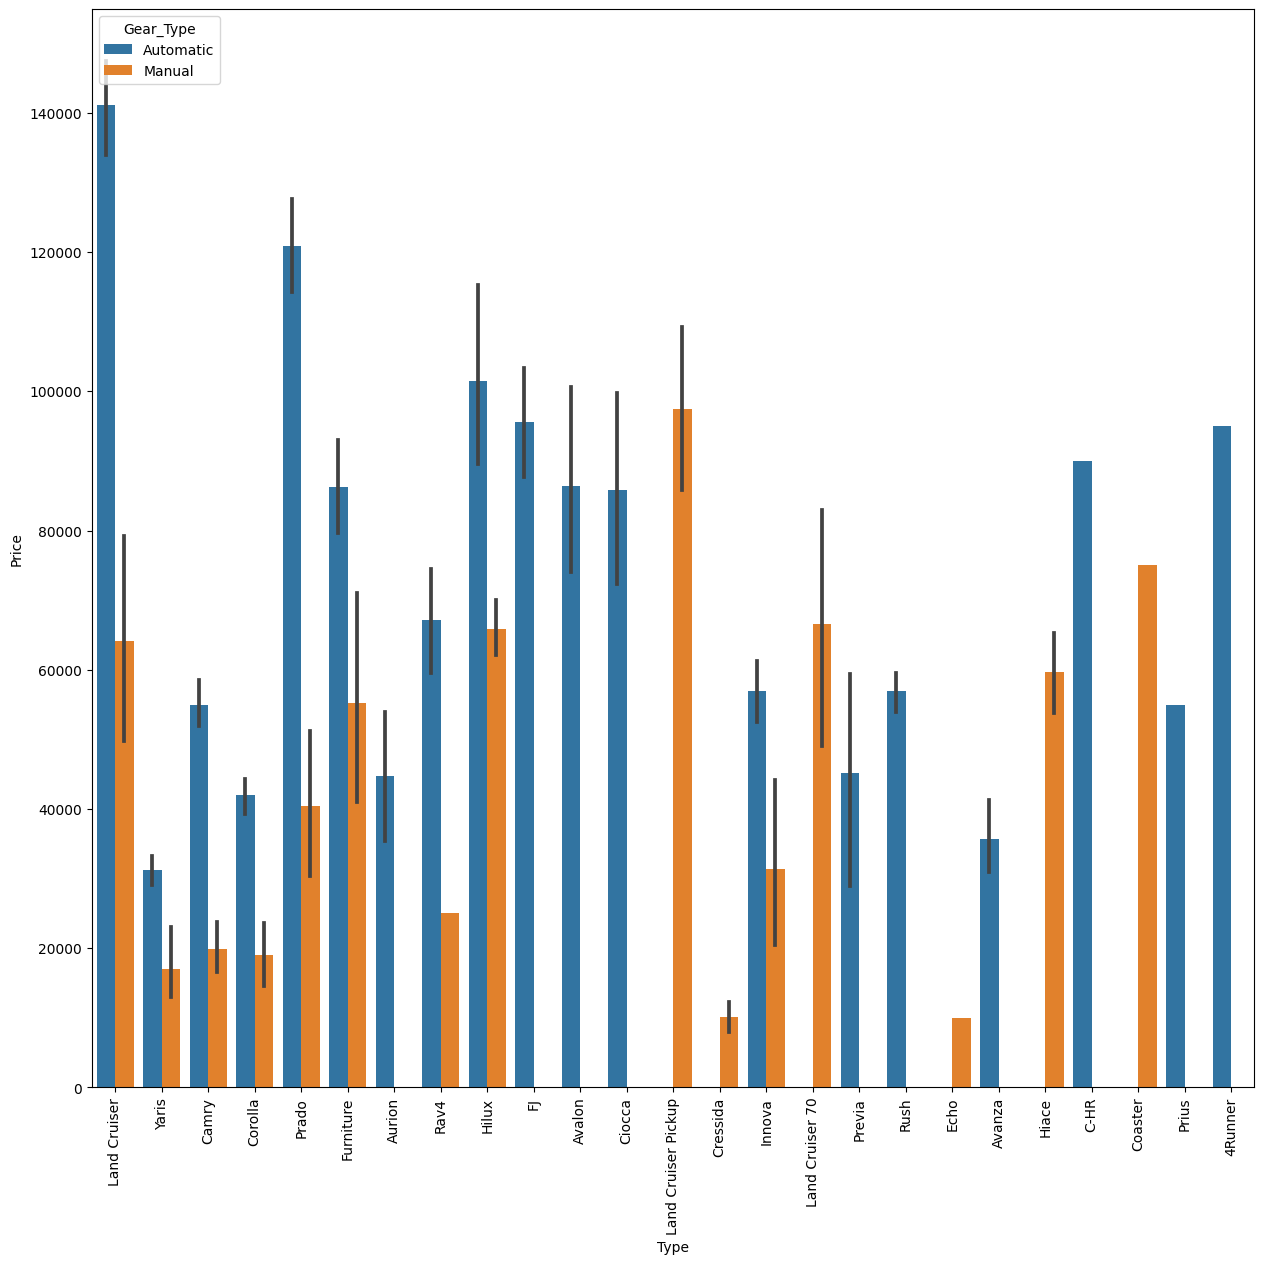

In [27]:
plt.figure(figsize=(15,14))
sns.barplot(data=toyota , x='Type' , y='Price' , hue='Gear_Type')
plt.xticks(rotation=90)
plt.show()

In [28]:
df2

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,Kia,Sorento,2006,Saudi,Navy,Full,3.5,Gas,Manual,257000,Dammam,15000.0,False
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False


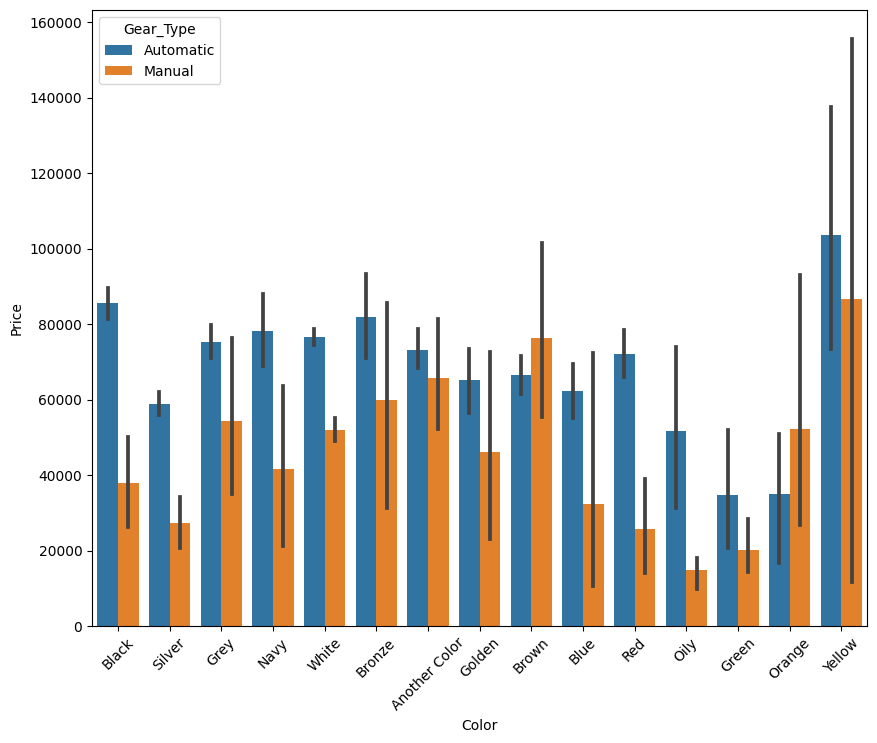

In [29]:
plt.figure(figsize=(10,8))
sns.barplot(data=df2 , x='Color' , y='Price' , hue='Gear_Type')
plt.xticks(rotation=45)
plt.show()

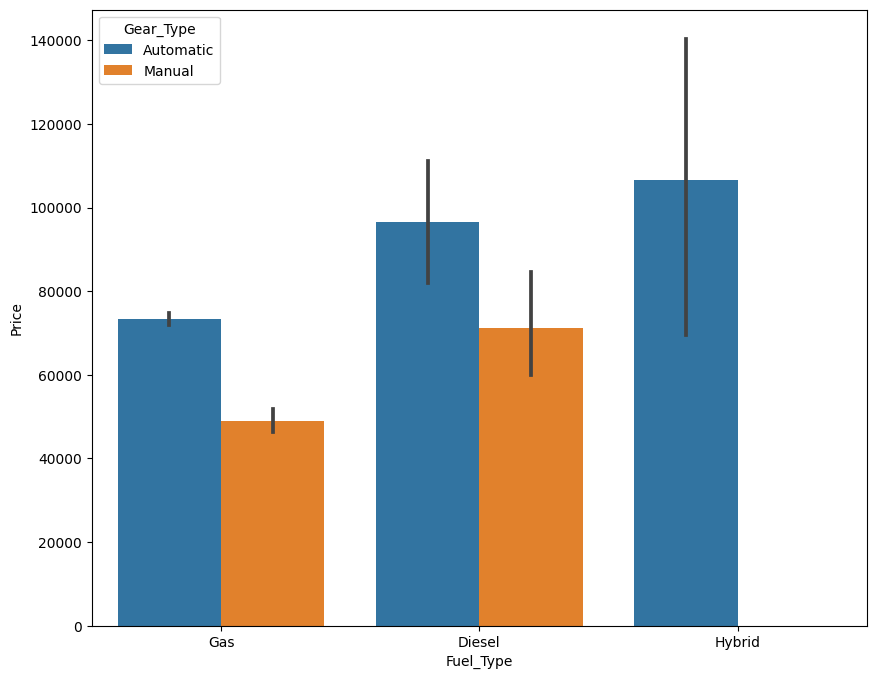

In [30]:
plt.figure(figsize=(10,8))
sns.barplot(data=df2 , x='Fuel_Type' , y='Price' , hue='Gear_Type')
plt.show()

In [31]:
df2

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,Kia,Sorento,2006,Saudi,Navy,Full,3.5,Gas,Manual,257000,Dammam,15000.0,False
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False


In [32]:
df['Fuel_Type'].value_counts()

Fuel_Type
Gas       7858
Diesel     151
Hybrid      23
Name: count, dtype: int64

In [33]:
df2.pivot_table(index='Make' , values='Price' , aggfunc='mean').reset_index()

,Make,Price
0,Aston Martin,182708.333333
1,Audi,109064.189189
2,BMW,112695.652174
3,BYD,28000.000000
4,Bentley,170758.928571
5,Cadillac,108171.875000
6,Changan,48513.513514
7,Chery,26750.000000
8,Chevrolet,66829.421986
9,Chrysler,68627.659574


In [34]:
pio.renderers.default = 'iframe_connected'
fig = px.pie(df2 , names='Gear_Type' , values='Price' )
fig.update_traces(textinfo='percent+label' , pull=[0.5 , 0])
fig.update_layout(
    width=1000,
    height=600
)
fig.show()

In [35]:
df2

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,Kia,Sorento,2006,Saudi,Navy,Full,3.5,Gas,Manual,257000,Dammam,15000.0,False
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False


In [36]:
pio.renderers.default = 'iframe_connected'
fig = px.histogram(df2 , x='Year' , color_discrete_sequence=['#636EFA'] , nbins=30)
fig.update_layout(
    width=1000,
    height=600
)
fig.show()

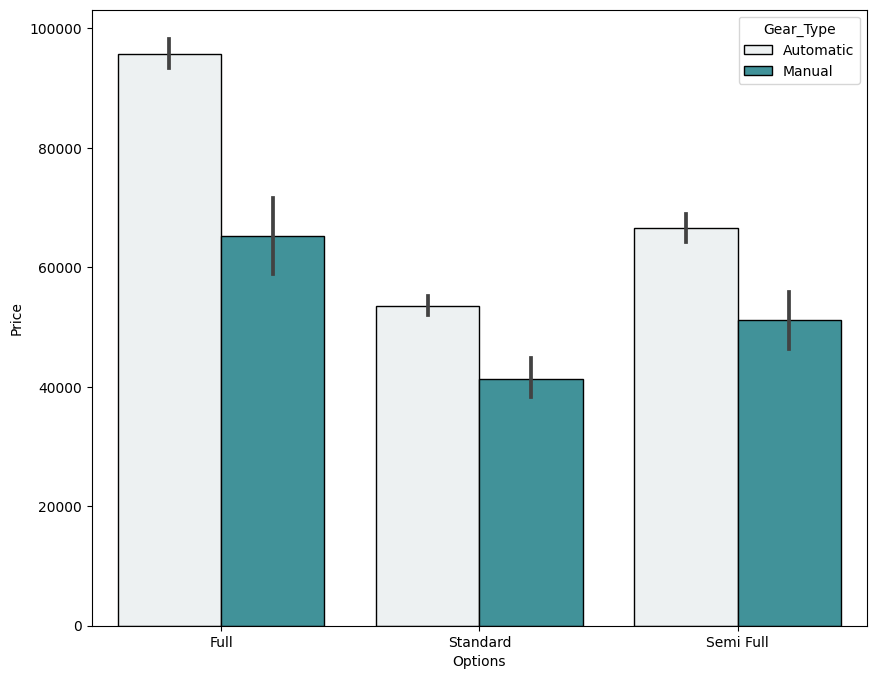

In [37]:
plt.figure(figsize=(10,8))
sns.barplot(data=df2 , x='Options' , y='Price' , hue='Gear_Type' , edgecolor='black' , color='#329ea8' )
plt.show()

In [38]:
df2["count_car"] = 2025 - df2["Year"]
df2

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable,count_car
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000.0,False,7
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500.0,False,6
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000.0,False,6
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500.0,False,6
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000.0,False,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8029,Kia,Sorento,2006,Saudi,Navy,Full,3.5,Gas,Manual,257000,Dammam,15000.0,False,19
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000.0,False,10
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000.0,False,15
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000.0,False,14
